---
# **Lab: Autoencoders**
---

# ▶️ CUDA tools...

In [ ]:
!nvidia-smi

# ✅ Basic Autoencoders

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

# helper function to visualize reconstructions

@torch.no_grad()
def show_reconstructions(model, loader, n=8):
    """ Visualize original and reconstructed images side by side."""
    model.eval()
    x, _ = next(iter(loader))
    x = x.to(device)
    x_hat = model(x).cpu()
    x = x.cpu()

    fig, axes = plt.subplots(2, n, figsize=(1.5*n, 3))
    for i in range(n):
        axes[0, i].imshow(x[i, 0], cmap="gray")
        axes[0, i].axis("off")
        axes[1, i].imshow(x_hat[i, 0], cmap="gray")
        axes[1, i].axis("off")
    axes[0, 0].set_title("Original", fontsize=10)
    axes[1, 0].set_title("Reconstruction", fontsize=10)
    plt.tight_layout()
    plt.show()

def visualize_samples(loader, num_samples=6): 
    """ Visualize a few samples from the dataset.
    """
    images, labels = next(iter(loader))
    fig, axes = plt.subplots(1, num_samples, figsize=(num_samples*1.5, 2))
    for i in range(num_samples):
        axes[i].imshow(images[i][0], cmap="gray")
        axes[i].set_title(str(labels[i].item()))
        axes[i].axis("off")
    plt.show()
     
# check if GPU is available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# data
transform = transforms.ToTensor()  # pixels in [0,1]
batch_size = 64
train_ds = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
test_ds  = datasets.MNIST(root="./data", train=False, download=True, transform=transform)

# data loaders
train_loader = DataLoader(train_ds, batch_size=128, shuffle=True, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds, batch_size=128, shuffle=False, num_workers=2, pin_memory=True)


100.0%
100.0%
100.0%
100.0%


Visualize some images...

/home/filippo/code/gpu/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


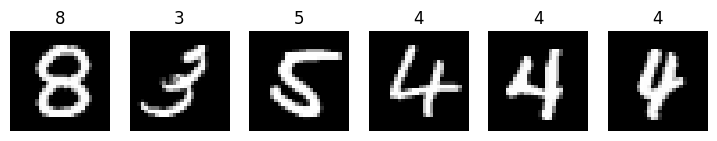

In [3]:
visualize_samples(train_loader)

#### Linear autoencoder

In [4]:
class Linear_AE(nn.Module):
    def __init__(self, latent_dim=32):
        super().__init__()
        self.encoder = nn.Linear(28*28, latent_dim)
        self.decoder = nn.Linear(latent_dim, 28*28)

    def forward(self, x):
        x = x.view(x.size(0), -1)     # (B, 784)
        z = self.encoder(x)           # (B, d)
        x_hat = self.decoder(z)       # (B, 784)
        return x_hat.view(-1, 1, 28, 28)

    def encode(self, x):
        x = x.view(x.size(0), -1)
        return self.encoder(x)

    def decode(self, z):
        x_hat = self.decoder(z)
        return x_hat.view(-1, 1, 28, 28)

In [ ]:
# model definition, loss function, optimizer

latent_dim = 64 # try changing this and see what happens to the latent space!
model = Linear_AE(latent_dim=latent_dim).to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

In [6]:
def train_epoch(model, loader):
    model.train()
    total = 0.0
    for x, _ in loader:
        x = x.to(device)
        x_hat = model(x)
        loss = criterion(x_hat, x)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total += loss.item() * x.size(0)
    return total / len(loader.dataset)

@torch.no_grad()
def eval_epoch(model, loader):
    model.eval()
    total = 0.0
    for x, _ in loader:
        x = x.to(device)
        x_hat = model(x)
        loss = criterion(x_hat, x)
        total += loss.item() * x.size(0)
    return total / len(loader.dataset)

In [8]:
epochs = 3
for epoch in range(1, epochs + 1):
    tr = train_epoch(model, train_loader)
    te = eval_epoch(model, test_loader)
    print(f"Epoch {epoch:02d} | train MSE: {tr:.5f} | test MSE: {te:.5f}")

Epoch 01 | train MSE: 0.01021 | test MSE: 0.00953
Epoch 02 | train MSE: 0.00965 | test MSE: 0.00928
Epoch 03 | train MSE: 0.00950 | test MSE: 0.00933


/home/filippo/code/gpu/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


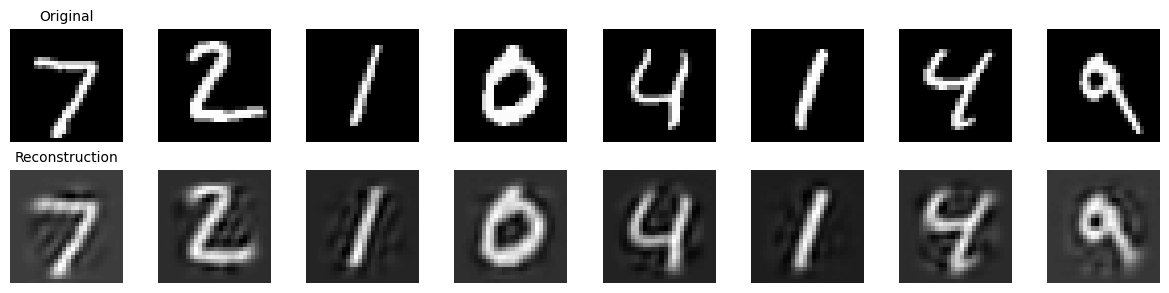

In [9]:
show_reconstructions(model, test_loader, n=8)

#### Deep autoencoder 

In [ ]:
# Deep autoencoder with fully connected layers
class deep_AE(nn.Module):
    def __init__(self, latent_dim=32):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(28*28, 256),
            nn.ReLU(),
            nn.Linear(256, latent_dim),
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 28*28),
            nn.Sigmoid()
        )
           
    def forward(self, x):
        x = x.view(x.size(0), -1)     # (B, 784)
        z = self.encoder(x)           # (B, d)
        x_hat = self.decoder(z)       # (B, 784)
        return x_hat.view(-1, 1, 28, 28)

    def encode(self, x):
        x = x.view(x.size(0), -1)
        return self.encoder(x)

    def decode(self, z):
        x_hat = self.decoder(z)
        return x_hat.view(-1, 1, 28, 28)

In [ ]:
# model definition, loss function, optimizer
model = FCAutoencoder(latent_dim=32).to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

In [ ]:
def train_epoch(model, loader):
    model.train()
    total = 0.0
    for x, _ in loader:
        x = x.to(device)
        x_hat = model(x)
        loss = criterion(x_hat, x)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total += loss.item() * x.size(0)
    return total / len(loader.dataset)

@torch.no_grad()
def eval_epoch(model, loader):
    model.eval()
    total = 0.0
    for x, _ in loader:
        x = x.to(device)
        x_hat = model(x)
        loss = criterion(x_hat, x)
        total += loss.item() * x.size(0)
    return total / len(loader.dataset)

In [ ]:
epochs = 10
for epoch in range(1, epochs + 1):
    tr = train_epoch(model, train_loader)
    te = eval_epoch(model, test_loader)
    print(f"Epoch {epoch:02d} | train MSE: {tr:.5f} | test MSE: {te:.5f}")

In [ ]:
show_reconstructions(model, test_loader, n=8)

In [ ]:
@torch.no_grad()
def collect_latents(model, loader, max_batches=50):
    model.eval()
    Z, Y = [], []
    for i, (x, y) in enumerate(loader):
        if i >= max_batches:
            break
        x = x.to(device)
        z = model.encode(x).cpu()
        Z.append(z)
        Y.append(y)
    return torch.cat(Z, dim=0), torch.cat(Y, dim=0)

Z, Y = collect_latents(model, test_loader)
print(Z.shape, Y.shape)

# ✅ Convolutional Autoencoders

In [10]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

# helper function to visualize reconstructions

@torch.no_grad()
def show_reconstructions(model, loader, n=8):
    """ Visualize original and reconstructed images side by side."""
    model.eval()
    x, _ = next(iter(loader))
    x = x.to(device)
    x_hat = model(x).cpu()
    x = x.cpu()

    fig, axes = plt.subplots(2, n, figsize=(1.5*n, 3))
    for i in range(n):
        axes[0, i].imshow(x[i, 0], cmap="gray")
        axes[0, i].axis("off")
        axes[1, i].imshow(x_hat[i, 0], cmap="gray")
        axes[1, i].axis("off")
    axes[0, 0].set_title("Original", fontsize=10)
    axes[1, 0].set_title("Reconstruction", fontsize=10)
    plt.tight_layout()
    plt.show()

def visualize_samples(loader, num_samples=6): 
    """ Visualize a few samples from the dataset.
    """
    images, labels = next(iter(loader))
    fig, axes = plt.subplots(1, num_samples, figsize=(num_samples*1.5, 2))
    for i in range(num_samples):
        axes[i].imshow(images[i][0], cmap="gray")
        axes[i].set_title(str(labels[i].item()))
        axes[i].axis("off")
    plt.show()
     
# check if GPU is available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# data
transform = transforms.ToTensor()  # pixels in [0,1]
batch_size = 64
train_ds = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
test_ds  = datasets.MNIST(root="./data", train=False, download=True, transform=transform)

# data loaders
train_loader = DataLoader(train_ds, batch_size=128, shuffle=True, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds, batch_size=128, shuffle=False, num_workers=2, pin_memory=True)


## ↘️ TODO...

**Build a Convolutional Autoencoder for MNIST (with TODO layers)**


Implement a convolutional autoencoder where:
-	Encoder: $1\times 28 \times 28 \to \text{latent channels} \times 7 \times 7$
-	Decoder: $\text{latent channels} \times 7 \times 7 \to 1\times 28 \times 28$

You must fill in the TODO layers using `nn.Conv2d` and `nn.ConvTranspose2d`


What you need to respect

```
Encoder target shapes
	Conv2d: 28 → 14
	Conv2d: 14 → 7
	Conv2d: 7 → 7 (keep size)

Decoder target shapes
	ConvTranspose2d: 7 → 7 (keep size)
	ConvTranspose2d: 7 → 14
	ConvTranspose2d: 14 → 28
```

**Constraints / hints**

How to halve spatial size

To go from $H \to H/2$ reliably, use (common choice):
-	kernel_size=3, stride=2, padding=1

This maps:
-	28 → 14
-	14 → 7

How to keep spatial size

To map 7 → 7:
-	kernel_size=3, stride=1, padding=1

How to double spatial size

To map 7 → 14 and 14 → 28, a robust transposed conv is:
-	kernel_size=4, stride=2, padding=1


In [66]:
import torch
import torch.nn as nn

class ConvAE(nn.Module):
    def __init__(self, latent_channels=16):
        super().__init__()

        # Encoder: 1x28x28 -> latent_channels x 7 x 7
        self.encoder = nn.Sequential(
            # TODO conv2d: 28 -> 14
            nn.Conv2d(
                in_channels=1, # This is the number of channels of MNIST images (grayscale)
                out_channels=16, # This is a random choice, it's just the number of filters in the first layer
                kernel_size=3,
                stride=2,
                padding=1,
            ),
            nn.ReLU(),
            nn.Conv2d(
                in_channels=16, # This is the number of channels of MNIST images (grayscale)
                out_channels=32, # This is a random choice, it's just the number of filters in the first layer
                kernel_size=3,
                stride=2,
                padding=1,
            ),
            nn.ReLU(),
            nn.Conv2d(
                in_channels=32, # This is the number of channels of MNIST images (grayscale)
                out_channels=64, # This is a random choice, it's just the number of filters in the first layer
                kernel_size=3,
                stride=1,
                padding=1,
            ),
            nn.ReLU(),
        )

        # Decoder: latent_channels x 7 x 7 -> 1x28x28
        self.decoder = nn.Sequential(
            # TODO convTranspose2d: 7 -> 7
            nn.ConvTranspose2d(
                in_channels=64, # This is the number of channels of MNIST images (grayscale)
                out_channels=32, # This is a random choice, it's just the number of filters in the first layer
                kernel_size=3,
                stride=1,
                padding=1,
            ),
            nn.ReLU(),
            nn.ConvTranspose2d(
                in_channels=32, # This is the number of channels of MNIST images (grayscale)
                out_channels=16, # This is a random choice, it's just the number of filters in the first layer
                kernel_size=3,
                stride=2,
                padding=1,
                output_padding=1
            ),
            nn.ReLU(),
            nn.ConvTranspose2d(
                in_channels=16, # This is the number of channels of MNIST images (grayscale)
                out_channels=1, # This is a random choice, it's just the number of filters in the first layer
                kernel_size=3,
                stride=2,
                padding=1,
                output_padding=1
            ),
            nn.Sigmoid()
        )

    def forward(self, x):
        z = self.encoder(x)
        x_hat = self.decoder(z)
        return x_hat

In [67]:
model = ConvAE(latent_channels=32).to(device)
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

def train_epoch(model, loader):
    model.train()
    total = 0.0
    for x, _ in loader:
        x = x.to(device)
        x_hat = model(x)
        loss = criterion(x_hat, x)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total += loss.item() * x.size(0)
    return total / len(loader.dataset)

@torch.no_grad()
def eval_epoch(model, loader):
    model.eval()
    total = 0.0
    for x, _ in loader:
        x = x.to(device)
        x_hat = model(x)
        loss = criterion(x_hat, x)
        total += loss.item() * x.size(0)
    return total / len(loader.dataset)

In [68]:
epochs = 3
for epoch in range(1, epochs + 1):
    tr = train_epoch(model, train_loader)
    te = eval_epoch(model, test_loader)
    print(f"Epoch {epoch:02d} | train MSE: {tr:.5f} | test MSE: {te:.5f}")

Epoch 01 | train MSE: 0.38858 | test MSE: 0.15805
Epoch 02 | train MSE: 0.11464 | test MSE: 0.09085
Epoch 03 | train MSE: 0.08508 | test MSE: 0.07908


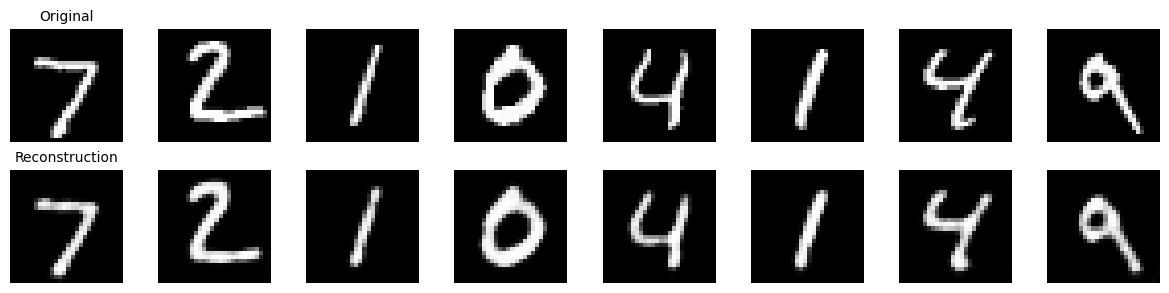

In [69]:
show_reconstructions(model, test_loader, n=8)

# ✅ Denoising Autoencoders

In [ ]:
#| label: imports
import torch, random, numpy as np
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

# reproducibility
seed = 42
random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

#| label: data
transform = transforms.ToTensor()   # pixels in [0,1]
train_ds = datasets.MNIST("./data", train=True, download=True, transform=transform)
test_ds  = datasets.MNIST("./data", train=False, download=True, transform=transform)

batch_size = 128
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

In [ ]:
# randomly add Gaussian noise to the input (clip to [0,1])
def add_gaussian_noise(x, sigma=0.2):
    """x in [0,1] -> clip to [0,1]"""
    return torch.clamp(x + sigma*torch.randn_like(x), 0.0, 1.0)

# randomly set pixel to 0 with probability p_mask (same shape)
def mask_random_pixels(x, p_mask=0.5):
    """Randomly set pixel to 0 with probability p_mask (same shape)"""
    mask = (torch.rand_like(x) > p_mask).float()
    return x * mask

# salt-and-pepper noise: randomly set pixels to 0 or 1 with probability p/2 each
def salt_and_pepper(x, p=0.2):
    """Salt-and-pepper: randomly set pixels to 0 or 1"""
    r = torch.rand_like(x)
    y = x.clone()
    y[r < p/2] = 0.0
    y[(r >= p/2) & (r < p)] = 1.0
    return y

# show denoising results
def show_denoise(model, loader, corruption_fn, n=8):
    model.eval()
    x, _ = next(iter(loader))
    x = x.to(device)[:n]
    x_noisy = corruption_fn(x)
    with torch.no_grad():
        x_hat = model(x_noisy)
    x = x.cpu(); x_noisy = x_noisy.cpu(); x_hat = x_hat.cpu()

    fig, axes = plt.subplots(3, n, figsize=(1.5*n, 4))
    for i in range(n):
        axes[0, i].imshow(x[i,0], cmap='gray'); axes[0,i].axis('off')
        axes[1, i].imshow(x_noisy[i,0], cmap='gray'); axes[1,i].axis('off')
        axes[2, i].imshow(x_hat[i,0], cmap='gray'); axes[2,i].axis('off')
    axes[0,0].set_ylabel("Clean")
    axes[1,0].set_ylabel("Noisy")
    axes[2,0].set_ylabel("Denoised")
    plt.tight_layout(); plt.show()

In [ ]:
# choose model, loss function, optimizer
#model = ConvAE(latent_channels=8).to(device)
model = deep_AE(latent_dim=32).to(device)

## ↘️ TODO...

In [ ]:
# training with MSE loss for pixel reconstruction (use BCEWithLogitsLoss if output is logits)
criterion = nn.MSELoss(reduction='mean')   # or nn.BCEWithLogitsLoss if using logits
optimizer = optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-5)

def train_epoch(model, loader, corruption_fn, sigma=0.2):

    # TODO: implement training loop with corruption_fn

    pass

@torch.no_grad()
def eval_epoch(model, loader, corruption_fn):
    
    # TODO: implement evaluation loop with corruption_fn
    
    pass

In [ ]:
# run
n_epochs = 15
corruption_fn = lambda x: add_gaussian_noise(x, sigma=0.3)
for epoch in range(1, n_epochs+1):
    tr = train_epoch(model, train_loader, corruption_fn)
    te = eval_epoch(model, test_loader, corruption_fn)
    print(f"Epoch {epoch:02d} | train {tr:.4f} | test {te:.4f}")

In [ ]:
show_denoise(model, test_loader, corruption_fn, n=8)

# ✅ Variational Autoencoder (VAE)

In [ ]:
# VAE on MNIST (PyTorch) — full working code (train + reconstructions + sampling + interpolation)

import math
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

# ----------------------------
# 0) Setup
# ----------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(42)

# ----------------------------
# 1) Data
# ----------------------------
transform = transforms.ToTensor()  # MNIST in [0,1]
train_ds = datasets.MNIST("./data", train=True, download=True, transform=transform)
test_ds  = datasets.MNIST("./data", train=False, download=True, transform=transform)

batch_size = 128
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

# ----------------------------
# 2) Model (MLP VAE)
# ----------------------------
class VAE(nn.Module):
    def __init__(self, input_dim=784, hidden_dim=400, latent_dim=20):
        super().__init__()
        self.input_dim = input_dim
        self.hidden_dim = hidden_dim
        self.latent_dim = latent_dim

        # encoder
        self.enc = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(inplace=True),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(inplace=True),
        )
        self.fc_mu = nn.Linear(hidden_dim, latent_dim)
        self.fc_logvar = nn.Linear(hidden_dim, latent_dim)

        # decoder
        self.dec = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim),
            nn.ReLU(inplace=True),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(inplace=True),
            nn.Linear(hidden_dim, input_dim),
        )
    
    def encode(self, x):
        h = self.enc(x)
        return self.fc_mu(h), self.fc_logvar(h)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode_logits(self, z):
        return self.dec(z)

    def forward(self, x):
        x = x.view(x.size(0), -1)
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        logits = self.decode_logits(z)
        return logits, mu, logvar

latent_dim = 20
vae = VAE(latent_dim=latent_dim).to(device)

# ----------------------------
# 3) Loss (ELBO)
# ----------------------------
bce_logits = nn.BCEWithLogitsLoss(reduction="sum")

def elbo_loss(x, logits, mu, logvar):
    """
    x: (B,784) in [0,1]
    logits: (B,784)
    mu, logvar: (B,latent_dim)
    """
    # Reconstruction term (negative log-likelihood under Bernoulli)
    recon = bce_logits(logits, x)

    # KL(q||p) with q=N(mu, diag(sigma^2)), p=N(0,I)
    # KL = -0.5 * sum(1 + logvar - mu^2 - exp(logvar))
    kl = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())

    return recon + kl, recon, kl

# ----------------------------
# 4) Train / Eval
# ----------------------------
optimizer = optim.Adam(vae.parameters(), lr=1e-3)

def run_epoch(model, loader, train=True):
    model.train(train)
    total, total_recon, total_kl = 0.0, 0.0, 0.0
    n = 0

    for x, _ in loader:
        x = x.to(device)
        x_flat = x.view(x.size(0), -1)

        logits, mu, logvar = model(x)
        loss, recon, kl = elbo_loss(x_flat, logits, mu, logvar)

        if train:
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        bs = x.size(0)
        total += loss.item()
        total_recon += recon.item()
        total_kl += kl.item()
        n += bs

    # we used sum reduction => divide by number of samples for per-sample averages
    return total / n, total_recon / n, total_kl / n

# ----------------------------
# 5) Visualization helpers
# ----------------------------
@torch.no_grad()
def show_reconstructions(model, loader, n=8):
    model.eval()
    x, _ = next(iter(loader))
    x = x.to(device)[:n]
    logits, mu, logvar = model(x)
    x_hat = torch.sigmoid(logits).view(-1, 1, 28, 28).cpu()
    x = x.cpu()

    fig, axes = plt.subplots(2, n, figsize=(1.5*n, 3))
    for i in range(n):
        axes[0, i].imshow(x[i,0], cmap="gray"); axes[0, i].axis("off")
        axes[1, i].imshow(x_hat[i,0], cmap="gray"); axes[1, i].axis("off")
    axes[0,0].set_title("Original", fontsize=10)
    axes[1,0].set_title("Reconstruction", fontsize=10)
    plt.tight_layout()
    plt.show()

@torch.no_grad()
def sample_from_prior(model, n=32):
    model.eval()
    z = torch.randn(n, model.latent_dim, device=device)
    logits = model.decode_logits(z)
    x = torch.sigmoid(logits).view(-1, 1, 28, 28).cpu()

    fig, axes = plt.subplots(4, 8, figsize=(8, 4))
    for i, ax in enumerate(axes.ravel()):
        ax.imshow(x[i,0], cmap="gray")
        ax.axis("off")
    plt.tight_layout()
    plt.show()

@torch.no_grad()
def interpolate_two(model, dataset, n_steps=10):
    model.eval()
    idx = torch.randint(0, len(dataset), (2,))
    x0, _ = dataset[idx[0].item()]
    x1, _ = dataset[idx[1].item()]
    x0 = x0.unsqueeze(0).to(device)
    x1 = x1.unsqueeze(0).to(device)

    mu0, logvar0 = model.encode(x0.view(1, -1))
    mu1, logvar1 = model.encode(x1.view(1, -1))
    # use means for deterministic interpolation
    z0, z1 = mu0.squeeze(0), mu1.squeeze(0)

    alphas = torch.linspace(0, 1, n_steps, device=device)
    imgs = []
    for a in alphas:
        z = (1-a)*z0 + a*z1
        logits = model.decode_logits(z.unsqueeze(0))
        imgs.append(torch.sigmoid(logits).view(28,28).cpu().numpy())

    fig, axes = plt.subplots(1, n_steps+2, figsize=(1.2*(n_steps+2), 2))
    axes[0].imshow(x0.cpu()[0,0], cmap="gray"); axes[0].axis("off"); axes[0].set_title("x")
    for i,a in enumerate(alphas):
        axes[i+1].imshow(imgs[i], cmap="gray"); axes[i+1].axis("off"); axes[i+1].set_title(f"{a.item():.1f}", fontsize=8)
    axes[-1].imshow(x1.cpu()[0,0], cmap="gray"); axes[-1].axis("off"); axes[-1].set_title("x'")
    plt.tight_layout()
    plt.show()

# ----------------------------
# 6) Run training
# ----------------------------
epochs = 10
for epoch in range(1, epochs+1):
    tr_loss, tr_recon, tr_kl = run_epoch(vae, train_loader, train=True)
    te_loss, te_recon, te_kl = run_epoch(vae, test_loader, train=False)
    print(
        f"Epoch {epoch:02d} | "
        f"Train: loss {tr_loss:.4f} (recon {tr_recon:.4f}, kl {tr_kl:.4f}) | "
        f"Test:  loss {te_loss:.4f} (recon {te_recon:.4f}, kl {te_kl:.4f})"
    )

# ----------------------------
# 7) Results
# ----------------------------
show_reconstructions(vae, test_loader, n=8)
sample_from_prior(vae, n=32)
interpolate_two(vae, test_ds, n_steps=10)